# 付録. 演習解答

各章の演習の解答(コード + 短い解説)です。**まず自力で試してから** 参照してください。
紙幅の都合で学習は小規模(少エポック・サブセット)にしてあり、傾向が読み取れる最小構成です。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, TensorDataset

from nn_textbook import datasets, metrics, plotting
from nn_textbook.models import MLP
from nn_textbook.training import set_seed, train_numpy_mlp, train_torch

set_seed(0)
device = torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)

## 01 章の解答

### 演習 1 — blobs の分散と線形モデル

`cluster_std` を上げるとクラスタが重なり、**どんなモデルでも到達できない精度の上限**
(ベイズ誤り率)自体が下がります。線形モデルの精度はそれに沿って低下します。

In [2]:
for std in [1.0, 2.0, 4.0]:
    X, y = datasets.make_blobs_dataset(n=300, centers=2, cluster_std=std, seed=0)
    acc = LogisticRegression().fit(X, y).score(X, y)
    print(f"cluster_std={std}: linear acc = {acc:.3f}")

cluster_std=1.0: linear acc = 0.973
cluster_std=2.0: linear acc = 0.843
cluster_std=4.0: linear acc = 0.747


### 演習 2 — 周波数を上げた関数近似

$\sin(4\pi x)$ は山谷が倍になるので、同じ幅では足りません。
必要な幅はターゲットの「曲がりの数」に応じて増えます。

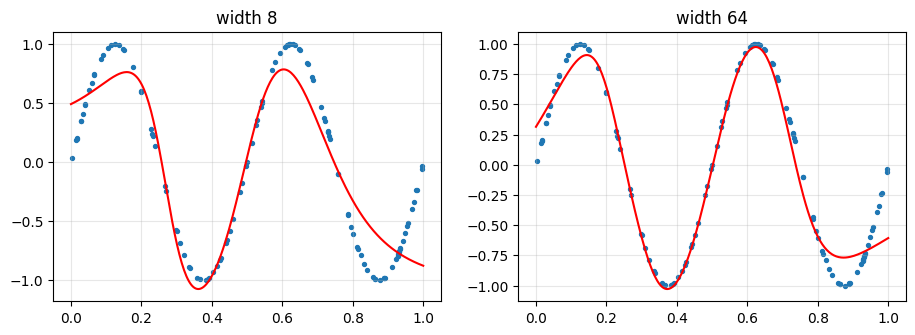

In [3]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 1, 120)).astype(np.float32)[:, None]
y = np.sin(4 * np.pi * x).astype(np.float32)
xs = np.linspace(0, 1, 300, dtype=np.float32)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, width in zip(axes, [8, 64], strict=True):
    m = MLP([1, width, width, 1], activation="tanh", task="regression", seed=0)
    train_numpy_mlp(m, x, y, lr=0.05, epochs=600, batch_size=32, seed=0)
    ax.scatter(x, y, s=8); ax.plot(xs, m.predict(xs), "r")
    ax.set_title(f"width {width}"); ax.grid(alpha=0.3)
plt.show()

### 演習 3 — moons のノイズと境界の滑らかさ

ノイズが大きいほどクラスが混ざり、境界はギザギザに(訓練データへの過適合が始まる)。

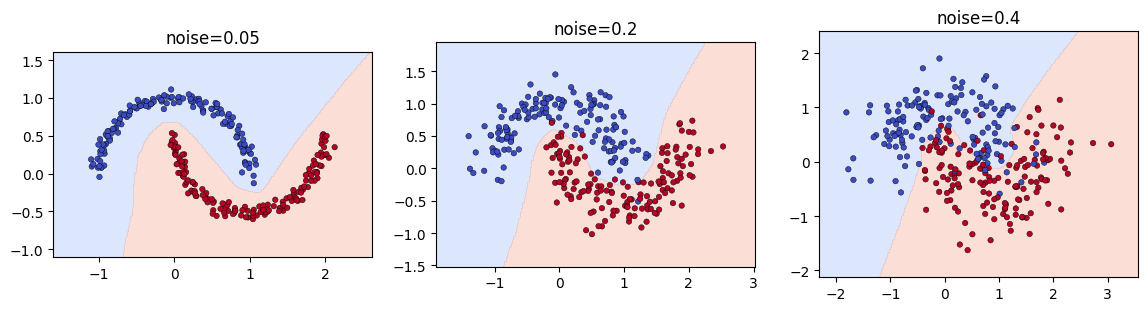

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, noise in zip(axes, [0.05, 0.2, 0.4], strict=True):
    X, y = datasets.make_moons_dataset(n=300, noise=noise, seed=0)
    m = MLP([2, 32, 32, 2], seed=0)
    train_numpy_mlp(m, X, y, lr=0.3, epochs=150, batch_size=32, seed=0)
    plotting.plot_decision_boundary(m.predict, X, y, ax=ax, title=f"noise={noise}")
plt.show()

### 演習 4 — circles に必要な容量

隠れ層 1 枚でも幅があれば分けられます。幅 4 では「円を囲む」表現力が足りず精度が落ちます。

In [5]:
Xc, yc = datasets.make_circles_dataset(n=300, noise=0.08, seed=0)
for sizes in [[2, 32, 2], [2, 4, 4, 2]]:
    m = MLP(sizes, seed=0)
    train_numpy_mlp(m, Xc, yc, lr=0.3, epochs=300, batch_size=32, seed=0)
    print(f"{str(sizes):16s}: acc = {metrics.accuracy(m.predict(Xc), yc):.3f}")

[2, 32, 2]      : acc = 1.000
[2, 4, 4, 2]    : acc = 1.000


### 演習 5 — relu と tanh の境界の見た目

ReLU ネットの境界は **折れ線的**(区分線形)、tanh は **滑らかな曲線** になります。
ReLU は区分線形関数しか表せないためです。

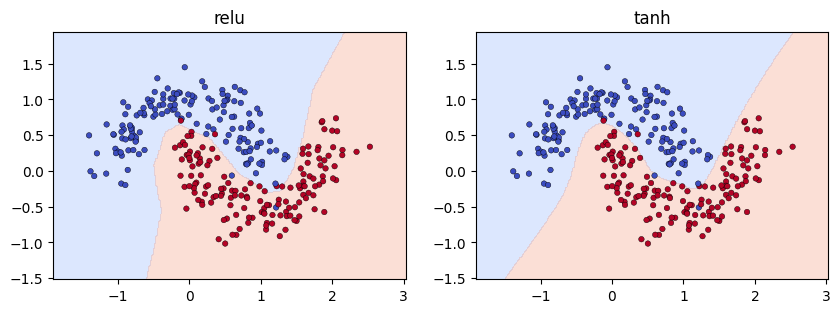

In [6]:
Xm, ym = datasets.make_moons_dataset(n=300, noise=0.2, seed=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, act in zip(axes, ["relu", "tanh"], strict=True):
    m = MLP([2, 16, 16, 2], activation=act, seed=0)
    train_numpy_mlp(m, Xm, ym, lr=0.3, epochs=200, batch_size=32, seed=0)
    plotting.plot_decision_boundary(m.predict, Xm, ym, ax=ax, title=act)
plt.show()

## 02 章の解答

### 演習 1 — $L = (ab + c)^2$ の勾配

手計算: $u = ab + c$, $L = u^2$ より
$\partial L/\partial a = 2u \cdot b$, $\partial L/\partial b = 2u \cdot a$, $\partial L/\partial c = 2u$。

In [7]:
from nn_textbook.autograd import Value

a, b, c = Value(2.0), Value(-3.0), Value(1.5)
L = (a * b + c) ** 2
L.backward()
u = 2.0 * -3.0 + 1.5
print(f"autograd: dL/da={a.grad}, dL/db={b.grad}, dL/dc={c.grad}")
print(f"by hand : dL/da={2*u*-3.0}, dL/db={2*u*2.0}, dL/dc={2*u}")

autograd: dL/da=27.0, dL/db=-18.0, dL/dc=-9.0
by hand : dL/da=27.0, dL/db=-18.0, dL/dc=-9.0


### 演習 2 — relu の勾配の 2 領域

活性前の値が正なら勾配は素通り、負なら **完全に 0**(その経路の学習が止まる)。

In [8]:
for b_val in [0.5, -2.0]:
    w, x_, b_ = Value(1.0), Value(1.0), Value(b_val)
    out = (w * x_ + b_).relu()
    out.backward()
    print(f"b={b_val:+.1f}: pre-act={1.0 + b_val:+.1f}  dout/dw={w.grad}, dout/db={b_.grad}")

b=+0.5: pre-act=+1.5  dout/dw=1.0, dout/db=1.0
b=-2.0: pre-act=-1.0  dout/dw=0.0, dout/db=0.0


### 演習 3 — 中心差分の刻み幅 $h$

$h$ が大きいと打ち切り誤差 $O(h^2)$、小さすぎると **桁落ち**(ほぼ等しい数の引き算)で悪化。
$10^{-5}$ 前後が最良という U 字になります。

In [9]:
import math

def f(w):
    return math.tanh(w * 1.5 - 0.5) ** 2

w0 = 0.8
x_ = Value(w0)
out = (x_ * 1.5 - 0.5).tanh() ** 2
out.backward()
exact = x_.grad
for h in [1e-2, 1e-6, 1e-10]:
    num = (f(w0 + h) - f(w0 - h)) / (2 * h)
    print(f"h={h:.0e}: numeric={num:.10f}  |error|={abs(num - exact):.2e}")

h=1e-02: numeric=1.1506923765  |error|=1.56e-04
h=1e-06: numeric=1.1508484652  |error|=2.67e-11
h=1e-10: numeric=1.1508485831  |error|=1.18e-07


### 演習 4 — 恒等関数の連鎖は勾配が消えない

局所微分が常に 1 なので、何段つないでも勾配は 1 のまま。
tanh の連鎖が縮むのは局所微分が 1 未満だからです。

In [10]:
x_ = Value(0.9)
out = x_
for _ in range(40):
    out = out * 1.0          # identity chain
out.backward()
print(f"identity chain depth 40: grad = {x_.grad}")

identity chain depth 40: grad = 1.0


### 演習 5 — sigmoid の勾配

$\sigma(x) = 1/(1 + e^{-x})$ を `exp` で組むと、勾配が $\sigma(x)(1 - \sigma(x))$ に一致します。

In [11]:
x_ = Value(0.7)
s = Value(1.0) / (Value(1.0) + (-x_).exp())
s.backward()
sv = s.data
print(f"autograd grad = {x_.grad:.8f}   sigma(1-sigma) = {sv * (1 - sv):.8f}")

autograd grad = 0.22171287   sigma(1-sigma) = 0.22171287


## 03 章の解答

### 演習 1 — Linear backward の shape(紙上)

$X: (N, d_\text{in})$, $G: (N, d_\text{out})$ として
$dW = X^\top G: (d_\text{in}, d_\text{out}) = W$ と同形、
$db = \sum_n G_n: (d_\text{out},) = b$ と同形、
$dX = G W^\top: (N, d_\text{in}) = X$ と同形。
「パラメータの勾配はパラメータと同形」が常に成り立ちます。

### 演習 2 — spiral での活性化比較

ReLU が最も速く収束します。sigmoid は出力が $(0,1)$ で中心がずれ、勾配も小さく遅い。

In [12]:
Xs, ys = datasets.make_spiral_dataset(n_per_class=150, n_classes=3, seed=0)
for act in ["relu", "tanh", "sigmoid"]:
    m = MLP([2, 64, 64, 3], activation=act, seed=0)
    h = train_numpy_mlp(m, Xs, ys, lr=0.5, epochs=200, batch_size=64, seed=0)
    print(f"{act:8s}: final loss={h['loss'][-1]:.3f}  acc={metrics.accuracy(m.predict(Xs), ys):.3f}")

relu    : final loss=0.055  acc=0.989


tanh    : final loss=0.023  acc=0.993


sigmoid : final loss=0.151  acc=0.956


### 演習 3 — バッチサイズの効果

小バッチは 1 エポックの更新回数が多く損失曲線はノイジー、大バッチは滑らかだが進みが遅い。

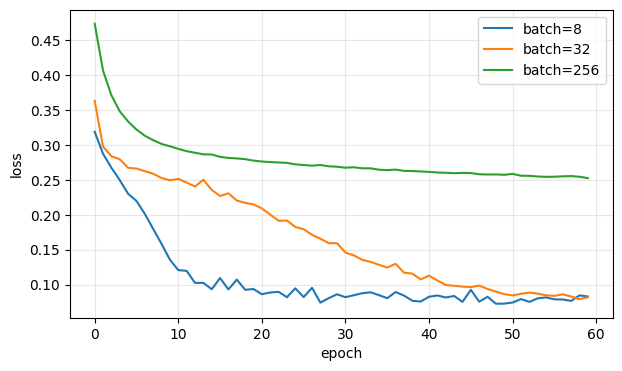

In [13]:
Xm, ym = datasets.make_moons_dataset(n=500, noise=0.2, seed=0)
fig, ax = plt.subplots(figsize=(7, 4))
for bs in [8, 32, 256]:
    m = MLP([2, 32, 32, 2], seed=0)
    h = train_numpy_mlp(m, Xm, ym, lr=0.1, epochs=60, batch_size=bs, seed=0)
    ax.plot(h["epoch"], h["loss"], label=f"batch={bs}")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.grid(alpha=0.3); ax.legend()
plt.show()

### 演習 4 — 幅 2 の隠れ表現は線形分離可能か

01 章の再現。隠れ表現の上で **線形** 分類器がほぼ完璧に分ける = 表現が線形分離可能。

In [14]:
Xc, yc = datasets.make_circles_dataset(n=400, noise=0.06, seed=0)
viz = MLP([2, 16, 2, 2], activation="relu", seed=0)
train_numpy_mlp(viz, Xc, yc, lr=0.3, epochs=400, batch_size=32, seed=0)
H = viz.hidden_representation(Xc, layer_index=-2)
lin_acc = LogisticRegression().fit(H, yc).score(H, yc)
print(f"linear classifier on hidden rep: acc = {lin_acc:.3f}")

linear classifier on hidden rep: acc = 0.863


### 演習 5 — 学習率過大で発散

損失が下がらず指数的に増えていきます(更新が谷を飛び越える)。

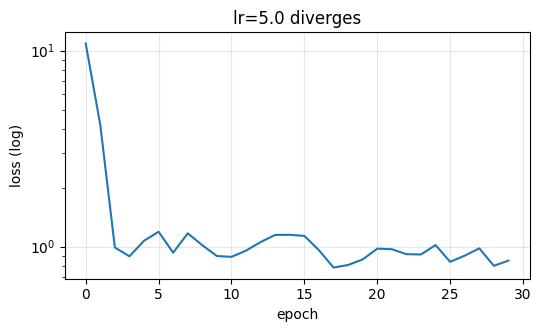

In [15]:
m = MLP([2, 32, 32, 2], seed=0)
h = train_numpy_mlp(m, Xm, ym, lr=5.0, epochs=30, batch_size=32, seed=0)
plt.figure(figsize=(6, 3.2))
plt.semilogy(h["epoch"], h["loss"])
plt.xlabel("epoch"); plt.ylabel("loss (log)"); plt.title("lr=5.0 diverges"); plt.grid(alpha=0.3)
plt.show()

### 演習 6(発展)— L2 正則化

更新を $\theta \leftarrow \theta - \eta(\nabla L + \lambda \theta)$ に変えるだけです(weight decay)。
小さな訓練集合で、正則化が train/val の差を縮めることを確認します。

In [16]:
def train_l2(model, X, y, lr, lam, epochs=200, bs=32, seed=0):
    rng = np.random.default_rng(seed)
    for _ in range(epochs):
        perm = rng.permutation(len(X))
        for s in range(0, len(X), bs):
            idx = perm[s:s + bs]
            model.loss(X[idx], y[idx]); model.backward()
            for p, g in model.params_and_grads():
                p -= lr * (g + lam * p)

Xs_tr, ys_tr, Xs_va, ys_va = datasets.train_val_split(*datasets.make_spiral_dataset(80, 3, noise=0.4, seed=0), 0.4, seed=0)
for lam in [0.0, 1e-3]:
    m = MLP([2, 128, 128, 3], seed=0)
    train_l2(m, Xs_tr, ys_tr, lr=0.5, lam=lam)
    tr_a = metrics.accuracy(m.predict(Xs_tr), ys_tr)
    va_a = metrics.accuracy(m.predict(Xs_va), ys_va)
    print(f"lambda={lam}: train={tr_a:.3f}  val={va_a:.3f}  gap={tr_a - va_a:.3f}")

lambda=0.0: train=0.979  val=0.906  gap=0.073
lambda=0.001: train=0.958  val=0.927  gap=0.031


## 04 章の解答

### 演習 1 — 初期化スケールと勾配ノルムの傾き

活性化勾配(本編 §1 と同じ指標)の入力側/出力側の比が、
スケールとともに「消失(比 ≪ 1)」から「爆発(比 ≫ 1)」へ移ります。
境目は分散を保つスケール(Xavier の $1/\sqrt{64} = 0.125$ 付近)です。

In [17]:
def deep_mlp(depth=12, width=64, std=0.01):
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.normal_(lin.weight, std=std); nn.init.zeros_(lin.bias)
        layers += [lin, nn.Tanh()]
    return nn.Sequential(*layers)

def act_grads(net, xb, tb):
    g = []
    for m in net:
        if isinstance(m, nn.Tanh):
            m.register_full_backward_hook(lambda mod, gi, go: g.append(go[0].norm().item()))
    ((net(xb) - tb) ** 2).mean().backward()
    return g[::-1]

set_seed(0)
xb, tb = torch.randn(64, 64), torch.randn(64, 64)
for std in [0.01, 0.1, 0.3, 1.0]:
    set_seed(0)
    g = act_grads(deep_mlp(std=std), xb, tb)
    print(f"std={std:4}: grad(layer1)/grad(layer12) = {g[0]/g[-1]:10.2e}")

std=0.01: grad(layer1)/grad(layer12) =   9.46e-13
std= 0.1: grad(layer1)/grad(layer12) =   6.49e-02
std= 0.3: grad(layer1)/grad(layer12) =   1.04e+01
std= 1.0: grad(layer1)/grad(layer12) =   1.81e+03


### 演習 2 — ReLU に Xavier を使うと

Xavier は ReLU の「半分が 0 になる」効果を補わないので、層が進むほど活性の分散が縮みます。

In [18]:
set_seed(0)
x_act = torch.randn(512, 64)
for init_name, gain in [("xavier", 1.0), ("he", 2.0**0.5)]:
    h = x_act
    stds = []
    for _ in range(10):
        lin = nn.Linear(64, 64)
        nn.init.normal_(lin.weight, std=gain / 64**0.5); nn.init.zeros_(lin.bias)
        h = torch.relu(lin(h))
        stds.append(h.std().item())
    print(f"{init_name:6s}: activation std layer1={stds[0]:.3f} ... layer10={stds[-1]:.3f}")

xavier: activation std layer1=0.588 ... layer10=0.018
he    : activation std layer1=0.825 ... layer10=0.502


### 演習 3 — LayerNorm でも悪い初期化を救えるか

救えます。LayerNorm はバッチでなく特徴方向の正規化ですが、
「層ごとに分布を整え直す」効果は同じです。

In [19]:
Xm4, ym4 = datasets.make_moons_dataset(n=600, noise=0.2, seed=0)
Xtr4, ytr4, Xva4, yva4 = datasets.train_val_split(Xm4, ym4, 0.2, seed=0)
tr4 = DataLoader(TensorDataset(torch.tensor(Xtr4), torch.tensor(ytr4)), batch_size=32, shuffle=True)
va4 = DataLoader(TensorDataset(torch.tensor(Xva4), torch.tensor(yva4)), batch_size=64)

def bad_init_net(norm=None, depth=8, width=64):
    layers = [nn.Linear(2, width)]
    for _ in range(depth):
        lin = nn.Linear(width, width)
        nn.init.normal_(lin.weight, std=0.01); nn.init.zeros_(lin.bias)
        layers.append(lin)
        if norm == "bn": layers.append(nn.BatchNorm1d(width))
        if norm == "ln": layers.append(nn.LayerNorm(width))
        layers.append(nn.Tanh())
    return nn.Sequential(*(layers + [nn.Linear(width, 2)]))

for norm in [None, "bn", "ln"]:
    set_seed(0)
    net = bad_init_net(norm)
    h = train_torch(net, tr4, loss_fn=nn.CrossEntropyLoss(),
                    optimizer=torch.optim.SGD(net.parameters(), lr=0.1),
                    epochs=20, device=device, val_loader=va4)
    print(f"norm={str(norm):4s}: val acc = {h['val_acc'][-1]:.3f}")

norm=None: val acc = 0.458


norm=bn  : val acc = 0.983


norm=ln  : val acc = 0.925


### 演習 4 — weight decay vs Dropout

どちらも train/val の差を縮めます。weight decay は重みを小さく保ち、
Dropout は特定ユニット依存を防ぐ — 機構は違えど目的は同じ正則化です。

In [20]:
fm_tr = datasets.load_fashion_mnist(train=True, n=1200, seed=0)
fm_va = datasets.load_fashion_mnist(train=False, n=800, seed=0)
Xf = torch.stack([i for i, _ in fm_tr]).reshape(-1, 784); yf = torch.tensor([l for _, l in fm_tr])
Xfv = torch.stack([i for i, _ in fm_va]).reshape(-1, 784); yfv = torch.tensor([l for _, l in fm_va])
trf = DataLoader(TensorDataset(Xf, yf), batch_size=64, shuffle=True)
vaf = DataLoader(TensorDataset(Xfv, yfv), batch_size=128)

def fnet(p=0.0):
    return nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Dropout(p), nn.Linear(256, 10))

for name, net, wd in [("plain", fnet(), 0.0), ("dropout 0.5", fnet(0.5), 0.0), ("weight decay", fnet(), 1e-3)]:
    set_seed(0)
    h = train_torch(net, trf, loss_fn=nn.CrossEntropyLoss(),
                    optimizer=torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=wd),
                    epochs=15, device=device, val_loader=vaf)
    print(f"{name:13s}: train_loss={h['train_loss'][-1]:.3f}  val_loss={h['val_loss'][-1]:.3f}  val_acc={h['val_acc'][-1]:.3f}")

plain        : train_loss=0.336  val_loss=0.638  val_acc=0.771


dropout 0.5  : train_loss=0.464  val_loss=0.634  val_acc=0.786


weight decay : train_loss=0.357  val_loss=0.637  val_acc=0.766


### 演習 5 — 残差の深さ依存

plain は深いほど入力側の勾配が消えるのに対し、残差は 60 層でもほぼフラットです。

In [21]:
class DeepNet(nn.Module):
    def __init__(self, depth, residual):
        super().__init__()
        self.blocks = nn.ModuleList([nn.Linear(64, 64) for _ in range(depth)])
        self.residual = residual
    def forward(self, x):
        for blk in self.blocks:
            out = torch.relu(blk(x))
            x = x + out if self.residual else out
        return x

for depth in [10, 30, 60]:
    row = []
    for res in [False, True]:
        set_seed(0)
        net = DeepNet(depth, res)
        ((net(torch.randn(32, 64)) - torch.randn(32, 64)) ** 2).mean().backward()
        g = [b.weight.grad.norm().item() for b in net.blocks]
        # Guard: at depth 60 the plain net's input-side gradient underflows to 0.
        ratio = g[-1] / g[0] if g[0] > 0 else float("inf")
        row.append(f"{'res' if res else 'plain':5s} ratio={ratio:8.1e}")
    print(f"depth {depth:>2}: " + "   ".join(row))

depth 10: plain ratio= 1.7e+02   res   ratio= 2.7e+00
depth 30: plain ratio= 7.0e+09   res   ratio= 3.1e+00
depth 60: plain ratio=     inf   res   ratio= 3.0e+00


### 演習 6 — SGD が振動し始める学習率

二次関数 $f = \frac{1}{2}(\lambda_1 x^2 + y^2)$ では安定条件は $\eta < 2/\lambda_1$。
係数(最大固有値)を変えると閾値もちょうど反比例して動きます。

In [22]:
for lam1 in [4.0, 8.0, 16.0]:
    threshold = 2.0 / lam1
    for eta in [threshold * 0.95, threshold * 1.05]:
        w = torch.tensor([-3.0, 3.0])
        for _ in range(60):
            w = w - eta * torch.tensor([lam1 * w[0], w[1]])
        status = "stable " if torch.isfinite(w).all() and w.abs().max() < 10 else "diverged"
        print(f"lam1={lam1:4}: eta={eta:.4f} ({eta*lam1/2:.2f} of threshold) -> {status}")

lam1= 4.0: eta=0.4750 (0.95 of threshold) -> stable 
lam1= 4.0: eta=0.5250 (1.05 of threshold) -> diverged
lam1= 8.0: eta=0.2375 (0.95 of threshold) -> stable 
lam1= 8.0: eta=0.2625 (1.05 of threshold) -> diverged
lam1=16.0: eta=0.1187 (0.95 of threshold) -> stable 
lam1=16.0: eta=0.1313 (1.05 of threshold) -> diverged


## 05 章の解答

### 演習 1 — 出力サイズ式の確認

In [23]:
from scipy.signal import convolve2d

def conv_out(n, k, p, s):
    return (n + 2 * p - k) // s + 1

img = np.asarray(datasets.load_mnist(train=True, n=1, seed=2)[0][0]).squeeze()
k = 3
for p, s in [(0, 1), (1, 1), (0, 2), (1, 2)]:
    expected = conv_out(28, k, p, s)
    # naive conv from ch.05
    xpad = np.pad(img, p)
    out_h = (xpad.shape[0] - k) // s + 1
    print(f"p={p} s={s}: formula={expected}, actual={out_h}")

p=0 s=1: formula=26, actual=26
p=1 s=1: formula=28, actual=28
p=0 s=2: formula=13, actual=13
p=1 s=2: formula=14, actual=14


### 演習 2 — FMNIST の 2・3 番目の混同ペア

本編の混同行列の上位ペアの実画像を見ると、人間にも紛らわしいことが分かります。
(時間節約のため小さなモデル・短い学習で再現。)

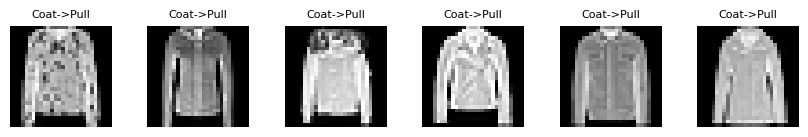

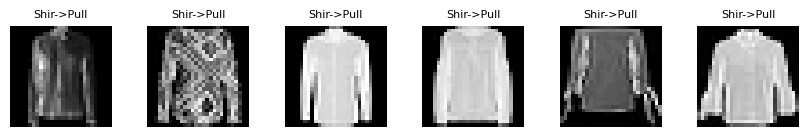

In [24]:
from nn_textbook.models import make_small_cnn

ftr = datasets.load_fashion_mnist(train=True, n=4000, seed=0)
fva = datasets.load_fashion_mnist(train=False, n=1500, seed=0)
Xft = torch.stack([i for i, _ in ftr]); yft = torch.tensor([l for _, l in ftr])
Xfv2 = torch.stack([i for i, _ in fva]); yfv2 = torch.tensor([l for _, l in fva])
set_seed(0)
fcnn = make_small_cnn()
train_torch(fcnn, DataLoader(TensorDataset(Xft, yft), batch_size=128, shuffle=True),
            loss_fn=nn.CrossEntropyLoss(), optimizer=torch.optim.Adam(fcnn.parameters(), 1e-3),
            epochs=2, device=device)
fcnn.eval()
with torch.no_grad():
    fp = fcnn(Xfv2).argmax(1)
cm = metrics.confusion_matrix(yfv2.numpy(), fp.numpy(), 10)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = [divmod(kk, 10) for kk in np.argsort(off.ravel())[::-1][:3]]
for rank, (i, j) in enumerate(pairs[1:3], start=2):
    sel = ((yfv2 == i) & (fp == j)).nonzero().ravel()[:6]
    plotting.plot_image_grid([Xfv2[s] for s in sel], ncols=6,
                             titles=[f"{datasets.FASHION_CLASSES[i][:4]}->{datasets.FASHION_CLASSES[j][:4]}"] * len(sel))
    plt.show()

### 演習 3〜5 — フィルタ数・プーリング・カーネルサイズ

短い学習(2 epoch・4000 枚)での比較。傾向: フィルタ数は精度とパラメータのトレードオフ、
avg pooling は max よりわずかに弱いことが多く(強い特徴を薄める)、
5x5 カーネルは受容野が広がる分パラメータが増えます。

In [25]:
mtr = datasets.load_mnist(train=True, n=4000, seed=0)
mva = datasets.load_mnist(train=False, n=1500, seed=0)
Xmt = torch.stack([i for i, _ in mtr]); ymt = torch.tensor([l for _, l in mtr])
Xmv = torch.stack([i for i, _ in mva]); ymv = torch.tensor([l for _, l in mva])
trm = DataLoader(TensorDataset(Xmt, ymt), batch_size=128, shuffle=True)
vam = DataLoader(TensorDataset(Xmv, ymv), batch_size=256)

def cnn_variant(c1=16, pool="max", k=3):
    P = nn.MaxPool2d(2) if pool == "max" else nn.AvgPool2d(2)
    pad = k // 2
    return nn.Sequential(
        nn.Conv2d(1, c1, k, padding=pad), nn.ReLU(), P,
        nn.Conv2d(c1, 2 * c1, k, padding=pad), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(2 * c1 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10))

variants = [("filters=8", dict(c1=8)), ("filters=16", dict(c1=16)), ("filters=32", dict(c1=32)),
            ("avg pool", dict(pool="avg")), ("kernel=5", dict(k=5))]
for name, kw in variants:
    set_seed(0)
    net = cnn_variant(**kw)
    h = train_torch(net, trm, loss_fn=nn.CrossEntropyLoss(),
                    optimizer=torch.optim.Adam(net.parameters(), 1e-3),
                    epochs=2, device=device, val_loader=vam)
    print(f"{name:11s}: params={metrics.count_parameters(net):>7,}  val_acc={h['val_acc'][-1]:.3f}")

filters=8  : params= 52,138  val_acc=0.799


filters=16 : params=105,866  val_acc=0.855


filters=32 : params=220,234  val_acc=0.894


avg pool   : params=105,866  val_acc=0.825


kernel=5   : params=114,314  val_acc=0.880


### 演習 6 — 2 層目の特徴マップ

1 層目はエッジなどの単純な特徴、2 層目はそれらを組み合わせた **より抽象的な部品**
(曲がり・交差など)に反応します。

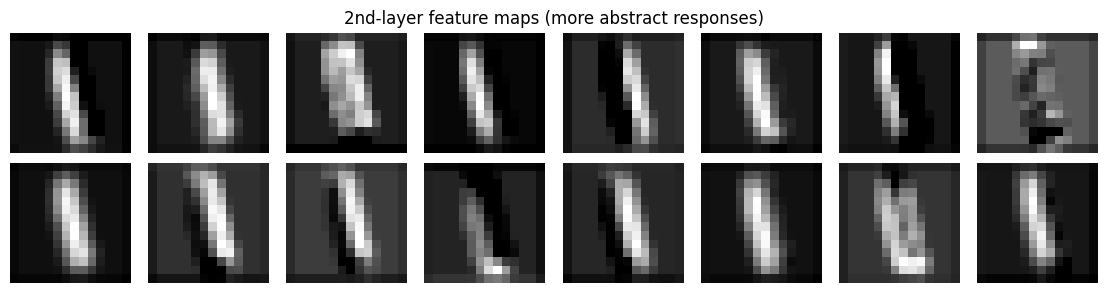

In [26]:
set_seed(0)
net = cnn_variant()
train_torch(net, trm, loss_fn=nn.CrossEntropyLoss(),
            optimizer=torch.optim.Adam(net.parameters(), 1e-3), epochs=2, device=device)
sample = Xmv[0:1]
with torch.no_grad():
    h1 = torch.relu(net[0](sample))
    h2 = torch.relu(net[3](net[2](h1)))[0]
plotting.plot_image_grid([h2[i].numpy() for i in range(16)], ncols=8)
plt.suptitle("2nd-layer feature maps (more abstract responses)", y=1.03)
plt.show()

## 06 章の解答

### 演習 1 — ウィンドウ幅の効果

正弦波の周期を覆える幅があれば十分。短すぎると文脈不足、長すぎても改善は頭打ちです。

In [27]:
from nn_textbook.models import make_rnn

t6, wave6 = datasets.make_sine_wave_dataset(n_steps=500, periods=8.0)

def seq_loaders(series, window):
    X, Y = datasets.make_sequence_windows(series, window=window)
    n_val = int(len(X) * 0.3)
    tr = DataLoader(TensorDataset(torch.tensor(X[:-n_val]), torch.tensor(Y[:-n_val])), batch_size=64, shuffle=True)
    va = DataLoader(TensorDataset(torch.tensor(X[-n_val:]), torch.tensor(Y[-n_val:])), batch_size=128)
    return tr, va

for w in [5, 20, 50]:
    tr6, va6 = seq_loaders(wave6, w)
    set_seed(0)
    m = make_rnn("gru", hidden_size=32)
    h = train_torch(m, tr6, loss_fn=nn.MSELoss(), optimizer=torch.optim.Adam(m.parameters(), 1e-2),
                    epochs=25, device=device, val_loader=va6)
    print(f"window={w:>2}: val MSE = {h['val_loss'][-1]:.6f}")

window= 5: val MSE = 0.000011


window=20: val MSE = 0.000026


window=50: val MSE = 0.000015


### 演習 2 — 勾配減衰と隠れ次元・活性化

減衰率は主に再帰重みのスペクトルと活性化の微分で決まります。
ReLU の RNN は減衰しにくい代わりに爆発しやすく、実務では使われません。

In [28]:
def grad_decay(seq_len=60, hidden=16, nonlinearity="tanh"):
    set_seed(0)
    rnn = nn.RNN(1, hidden, batch_first=True, nonlinearity=nonlinearity)
    x = torch.randn(1, seq_len, 1, requires_grad=True)
    out, _ = rnn(x)
    out[:, -1, :].sum().backward()
    g = x.grad[0, :, 0].abs()
    return (g[0] / g[-1]).item()      # how much smaller at the distant past

for hidden in [4, 64]:
    for nl in ["tanh", "relu"]:
        r = grad_decay(hidden=hidden, nonlinearity=nl)
        print(f"hidden={hidden:>2} {nl:4s}: grad(t=0)/grad(t=end) = {r:.2e}")

hidden= 4 tanh: grad(t=0)/grad(t=end) = 1.34e-20
hidden= 4 relu: grad(t=0)/grad(t=end) = 5.43e-31
hidden=64 tanh: grad(t=0)/grad(t=end) = 7.00e-13
hidden=64 relu: grad(t=0)/grad(t=end) = 8.40e-25


### 演習 3 — LSTM vs GRU(AR 過程)

GRU は LSTM よりパラメータが約 25% 少なく、この規模のタスクでは精度はほぼ同等です。

In [29]:
ar6 = datasets.make_ar_process_dataset(n_steps=500, seed=0)
tr6, va6 = seq_loaders(ar6, 15)
for kind in ["lstm", "gru"]:
    set_seed(0)
    m = make_rnn(kind, hidden_size=32)
    h = train_torch(m, tr6, loss_fn=nn.MSELoss(), optimizer=torch.optim.Adam(m.parameters(), 1e-2),
                    epochs=30, device=device, val_loader=va6)
    print(f"{kind.upper():4s}: params={metrics.count_parameters(m):>6,}  val MSE={h['val_loss'][-1]:.4f}")

LSTM: params= 4,513  val MSE=0.0432


GRU : params= 3,393  val MSE=0.0433


### 演習 4 — 強いノイズ下の平滑化

観測ノイズ分散(0.09)が予測 MSE の下限になります。それ以下には原理的に下げられません。

In [30]:
_, noisy6 = datasets.make_noisy_sine_wave_dataset(n_steps=500, periods=8.0, noise=0.3, seed=0)
tr6, va6 = seq_loaders(noisy6, 25)
set_seed(0)
m = make_rnn("lstm", hidden_size=32)
h = train_torch(m, tr6, loss_fn=nn.MSELoss(), optimizer=torch.optim.Adam(m.parameters(), 1e-2),
                epochs=30, device=device, val_loader=va6)
print(f"val MSE = {h['val_loss'][-1]:.4f}  vs noise variance = {0.3**2:.3f}")

val MSE = 0.1052  vs noise variance = 0.090


### 演習 5 — 勾配クリッピング

学習率を上げて不安定にしたとき、クリッピングは発散(loss の暴れ)を抑えます。

In [31]:
for clip in [None, 1.0]:
    set_seed(0)
    m = make_rnn("rnn", hidden_size=32)
    h = train_torch(m, tr6, loss_fn=nn.MSELoss(), optimizer=torch.optim.Adam(m.parameters(), 5e-2),
                    epochs=20, device=device, val_loader=va6, grad_clip=clip)
    print(f"grad_clip={str(clip):4s}: max train loss={max(h['train_loss']):.3f}  final val={h['val_loss'][-1]:.4f}")

grad_clip=None: max train loss=1.283  final val=0.1535


grad_clip=1.0 : max train loss=1.328  final val=0.1893


### 演習 6(発展)— 再帰的な多ステップ予測

1 ステップ予測モデルの出力を入力に戻して繰り返すと、誤差が複利的に蓄積し、
遠い未来ほど予測が崩れます。

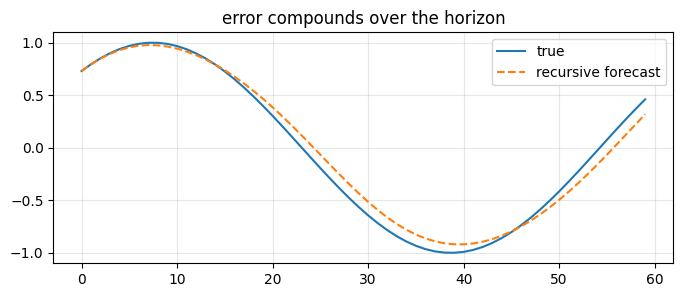

In [32]:
_, wave6c = datasets.make_sine_wave_dataset(n_steps=500, periods=8.0)
tr6, _ = seq_loaders(wave6c, 20)
set_seed(0)
m = make_rnn("gru", hidden_size=32)
train_torch(m, tr6, loss_fn=nn.MSELoss(), optimizer=torch.optim.Adam(m.parameters(), 1e-2),
            epochs=30, device=device)
m.eval()
ctx = torch.tensor(wave6c[300:320])[None, :, None]
preds = []
with torch.no_grad():
    for _ in range(60):
        nxt = m(ctx)
        preds.append(nxt.item())
        ctx = torch.cat([ctx[:, 1:], nxt[None]], dim=1)
true = wave6c[320:380]
plt.figure(figsize=(8, 3))
plt.plot(true, label="true"); plt.plot(preds, "--", label="recursive forecast")
plt.legend(); plt.grid(alpha=0.3); plt.title("error compounds over the horizon")
plt.show()

## 07 章の解答

### 演習 1 — Query を変えると注意の行が変わる

注意行列の第 $i$ 行は Query $i$ だけの関数なので、その行だけが変わります。

In [33]:
from nn_textbook.metrics import softmax_np

E7 = np.eye(4) + 0.1
def attn_of(E):
    s = E @ E.T / np.sqrt(E.shape[1])
    return softmax_np(s, axis=1)

A1 = attn_of(E7)
E7b = E7.copy(); E7b[2] = [5, -5, 5, -5]          # change only query/key 2
A2 = attn_of(E7b)
print("rows that changed:", [i for i in range(4) if not np.allclose(A1[i], A2[i], atol=1e-6)])

rows that changed: [0, 1, 2, 3]


### 演習 2〜4 — マスク・ヘッド数・位置エンコーディング

同じ TinyLM を条件を変えて短時間学習し、損失を比べます。

- **マスクなし** は損失が劇的に下がりますが、それは答え(次の文字そのもの)を
  入力中に見られる **カンニング** であり、生成には使えません。
- **ヘッド数** はこの規模では大差なし(タスクが単純なため)。
- **位置エンコーディングなし** は語順を失い、損失が悪化します。

In [34]:
text12 = datasets.make_tiny_text_corpus(repeat=40)
tok12 = datasets.CharTokenizer(text12)
data12 = torch.tensor(tok12.encode(text12))
BS = 32

class TinyLM12(nn.Module):
    def __init__(self, n_heads=4, use_pe=True, causal=True):
        super().__init__()
        d = 64
        self.use_pe, self.causal = use_pe, causal
        self.tok = nn.Embedding(tok12.vocab_size, d)
        self.pos = nn.Embedding(BS, d)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d, n_heads, 4 * d, dropout=0.0, batch_first=True, norm_first=True)
            for _ in range(2)])
        self.ln = nn.LayerNorm(d); self.head = nn.Linear(d, tok12.vocab_size)
    def forward(self, idx):
        T = idx.shape[1]
        x = self.tok(idx)
        if self.use_pe:
            x = x + self.pos(torch.arange(T, device=idx.device))
        mask = torch.triu(torch.full((T, T), float("-inf"), device=idx.device), 1) if self.causal else None
        for b in self.blocks:
            x = b(x, src_mask=mask)
        return self.head(self.ln(x))

def train_lm(model, steps=300):
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for _ in range(steps):
        ix = torch.randint(0, len(data12) - BS - 1, (32,))
        x = torch.stack([data12[i:i + BS] for i in ix])
        y = torch.stack([data12[i + 1:i + 1 + BS] for i in ix])
        loss = F.cross_entropy(model(x).reshape(-1, tok12.vocab_size), y.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

for name, kw in [("baseline (causal, PE, 4 heads)", {}), ("no causal mask (cheating)", {"causal": False}),
                 ("1 head", {"n_heads": 1}), ("no positional encoding", {"use_pe": False})]:
    set_seed(0)
    print(f"{name:32s}: loss after 300 steps = {train_lm(TinyLM12(**kw)):.3f}")

baseline (causal, PE, 4 heads)  : loss after 300 steps = 0.120


no causal mask (cheating)       : loss after 300 steps = 0.002


1 head                          : loss after 300 steps = 0.132


no positional encoding          : loss after 300 steps = 0.136


### 演習 5 — 生成温度

低温は確実だが反復的、高温は多様だが崩れる。0.8 前後が定番の妥協点です。

In [35]:
set_seed(0)
lm12 = TinyLM12()
train_lm(lm12, steps=600)

def gen(temp, n=80):
    idx = torch.tensor(tok12.encode("neural "))[None]
    lm12.eval()
    with torch.no_grad():
        for _ in range(n):
            logits = lm12(idx[:, -BS:])
            p = F.softmax(logits[0, -1] / temp, dim=-1)
            idx = torch.cat([idx, torch.multinomial(p, 1)[None]], dim=1)
    return tok12.decode(idx[0].tolist())

for temp in [0.2, 0.8, 1.5]:
    print(f"T={temp}: {gen(temp)!r}\n")

T=0.2: 'neural networks learn representations from data. a network is a composition of linear a'

T=0.8: 'neural networks learn representations from data. a network iourad neicomputa. ata. atte'

T=1.5: 'neural networks learn represok nearns. neural networks learn representations from datug'



### 演習 6(発展)— 文脈長

このミニコーパスは局所相関が支配的なので block_size=8 でもかなり下がりますが、
長い文脈はより長いフレーズの再現を可能にします。実データほど差が開きます。
(block_size を変える実験は `BS` を書き換えて再実行してください。)

## 08 章の解答

### 演習 1 — ボトルネック幅と再構成品質

In [36]:
from nn_textbook.models import make_autoencoder

mtr8 = datasets.load_mnist(train=True, n=4000, seed=0)
X8 = torch.stack([i for i, _ in mtr8]).reshape(-1, 784)
y8 = torch.tensor([l for _, l in mtr8])
loader8 = DataLoader(TensorDataset(X8), batch_size=128, shuffle=True)

def train_ae(latent, epochs=5, noise=0.0, beta=None):
    set_seed(0)
    if beta is None:
        net = make_autoencoder(latent_dim=latent, input_dim=784)
        opt = torch.optim.Adam(net.parameters(), 1e-3)
        for _ in range(epochs):
            for (xb,) in loader8:
                inp = (xb + noise * torch.randn_like(xb)).clamp(0, 1) if noise else xb
                recon, _ = net(inp)
                loss = F.mse_loss(recon, xb)
                opt.zero_grad(); loss.backward(); opt.step()
        return net, loss.item()
    return None, None

for latent in [2, 8, 32]:
    _, l = train_ae(latent)
    print(f"latent={latent:>2}: final recon MSE = {l:.4f}")

latent= 2: final recon MSE = 0.0654


latent= 8: final recon MSE = 0.0606


latent=32: final recon MSE = 0.0643


### 演習 2 — ノイズ強度と復元限界

ノイズが強いほど復元は「平均的な桁」に寄り、`noise=1.0` では入力情報がほぼ失われます。

In [37]:
for noise in [0.2, 0.5, 1.0]:
    _, l = train_ae(16, epochs=5, noise=noise)
    print(f"noise_std={noise}: denoising MSE = {l:.4f}")

noise_std=0.2: denoising MSE = 0.0673


noise_std=0.5: denoising MSE = 0.0672


noise_std=1.0: denoising MSE = 0.0670


### 演習 3 — β のトレードオフ

β が大きいほど KL は小さく(きれいな事前分布)、再構成は悪化します。
生成品質と再構成精度のトレードオフです。

In [38]:
from nn_textbook.models import make_vae

def train_vae(beta, epochs=6):
    set_seed(0)
    v = make_vae(latent_dim=2, input_dim=784)
    opt = torch.optim.Adam(v.parameters(), 1e-3)
    for _ in range(epochs):
        for (xb,) in loader8:
            recon, mu, logvar = v(xb)
            rl = F.binary_cross_entropy(recon, xb, reduction="sum") / len(xb)
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(xb)
            loss = rl + beta * kl
            opt.zero_grad(); loss.backward(); opt.step()
    return v, rl.item(), kl.item()

for beta in [0.1, 1.0, 4.0]:
    _, rl, kl = train_vae(beta)
    print(f"beta={beta:3}: recon={rl:7.2f}  KL={kl:6.3f}")

beta=0.1: recon= 182.69  KL=33.830


beta=1.0: recon= 185.38  KL= 8.403


beta=4.0: recon= 191.80  KL= 3.306


### 演習 4 — Fashion-MNIST の潜在空間

衣類カテゴリでもクラスタは現れますが、形の似たクラス(シャツ系)は潜在空間でも重なります。

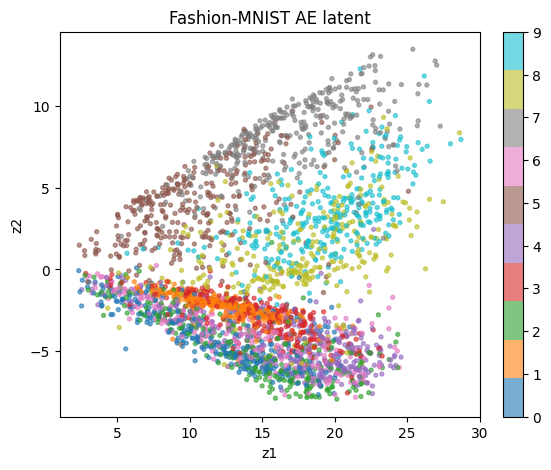

In [39]:
ftr8 = datasets.load_fashion_mnist(train=True, n=3000, seed=0)
Xf8 = torch.stack([i for i, _ in ftr8]).reshape(-1, 784)
yf8 = torch.tensor([l for _, l in ftr8])
set_seed(0)
ae_f = make_autoencoder(latent_dim=2, input_dim=784)
opt = torch.optim.Adam(ae_f.parameters(), 1e-3)
for _ in range(6):
    for (xb,) in DataLoader(TensorDataset(Xf8), batch_size=128, shuffle=True):
        recon, _ = ae_f(xb)
        loss = F.mse_loss(recon, xb)
        opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    _, Zf = ae_f(Xf8)
plotting.plot_latent_space(Zf.numpy(), yf8.numpy(), title="Fashion-MNIST AE latent")
plt.show()

### 演習 5 — 再構成誤差で外れ値検出

再構成誤差が大きいサンプル = モデルが「typical な桁」として説明できないもの。
崩れた字・珍しい書体が上位に来ます。

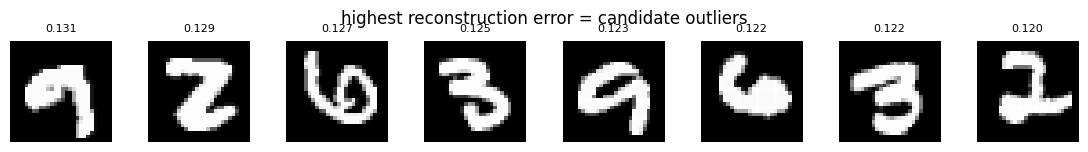

In [40]:
ae1, _ = train_ae(8, epochs=5)
ae1.eval()
with torch.no_grad():
    recon, _ = ae1(X8)
errors = ((recon - X8) ** 2).mean(dim=1)
worst = errors.argsort(descending=True)[:8]
plotting.plot_image_grid([X8[i].reshape(28, 28) for i in worst], ncols=8,
                         titles=[f"{errors[i]:.3f}" for i in worst])
plt.suptitle("highest reconstruction error = candidate outliers", y=1.05)
plt.show()

### 演習 6(発展)— posterior collapse

β を極端に上げると KL がほぼ 0(潜在が事前分布そのもの)になり、
デコーダは入力を無視した「平均画像」しか出せなくなります。

beta=50: recon=218.7  KL=0.0143  (KL ~ 0 -> latent carries no information)


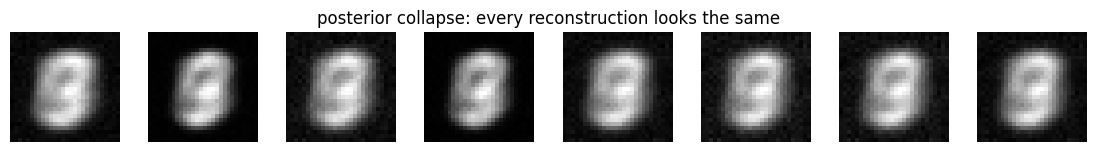

In [41]:
v50, rl, kl = train_vae(50.0, epochs=5)
print(f"beta=50: recon={rl:.1f}  KL={kl:.4f}  (KL ~ 0 -> latent carries no information)")
with torch.no_grad():
    recon, _, _ = v50(X8[:8])
plotting.plot_image_grid([recon[i].reshape(28, 28) for i in range(8)], ncols=8)
plt.suptitle("posterior collapse: every reconstruction looks the same", y=1.05)
plt.show()

## 09 章の解答

### 演習 1・2 — モード数と被覆の定量化

最近傍モードのヒストグラムで「どのモードに質量が行ったか」を数えます。
モード数が多いほど全被覆は難しくなります。崩壊設定では数モードに集中します。

In [42]:
from nn_textbook.models import make_gan_2d

def train_gan(n_modes, steps, seed, lr_g=2e-3, lr_d=2e-3, betas=(0.5, 0.9), hidden=64):
    X_real, _ = datasets.make_gaussian_mixture_dataset(n=800, n_components=n_modes, radius=2.0, std=0.12, seed=0)
    set_seed(seed)
    G, D = make_gan_2d(2, hidden)
    og = torch.optim.Adam(G.parameters(), lr=lr_g, betas=betas)
    od = torch.optim.Adam(D.parameters(), lr=lr_d, betas=betas)
    bce = nn.BCEWithLogitsLoss(); real = torch.tensor(X_real); B = 256
    for _ in range(steps):
        z = torch.randn(B, 2)
        od.zero_grad()
        (bce(D(real[torch.randint(0, len(real), (B,))]), torch.ones(B, 1))
         + bce(D(G(z).detach()), torch.zeros(B, 1))).backward()
        od.step()
        z = torch.randn(B, 2)
        og.zero_grad(); bce(D(G(z)), torch.ones(B, 1)).backward(); og.step()
    with torch.no_grad():
        return G(torch.randn(600, 2)).numpy()

def mode_hist(fake, n_modes):
    ang = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
    centers = 2.0 * np.c_[np.cos(ang), np.sin(ang)]
    near = np.linalg.norm(fake[:, None] - centers[None], axis=2).argmin(1)
    return np.bincount(near, minlength=n_modes)

for n_modes in [4, 8, 16]:
    fake = train_gan(n_modes, steps=800, seed=0)
    h = mode_hist(fake, n_modes)
    print(f"{n_modes:>2} modes, healthy: nonzero modes = {(h > 20).sum()}/{n_modes}")

fake_c = train_gan(8, steps=800, seed=3, lr_g=5e-3, lr_d=5e-4, betas=(0.9, 0.999), hidden=32)
print(f" 8 modes, collapse setup: hist = {mode_hist(fake_c, 8).tolist()}")

 4 modes, healthy: nonzero modes = 4/4


 8 modes, healthy: nonzero modes = 8/8


16 modes, healthy: nonzero modes = 16/16


 8 modes, collapse setup: hist = [0, 0, 0, 72, 528, 0, 0, 0]


### 演習 3 — 線形スケジュール

線形 $\bar\alpha_t = 1 - t$ は cosine より早く信号を壊します(中盤の劣化が急)。
cosine が好まれる理由です。

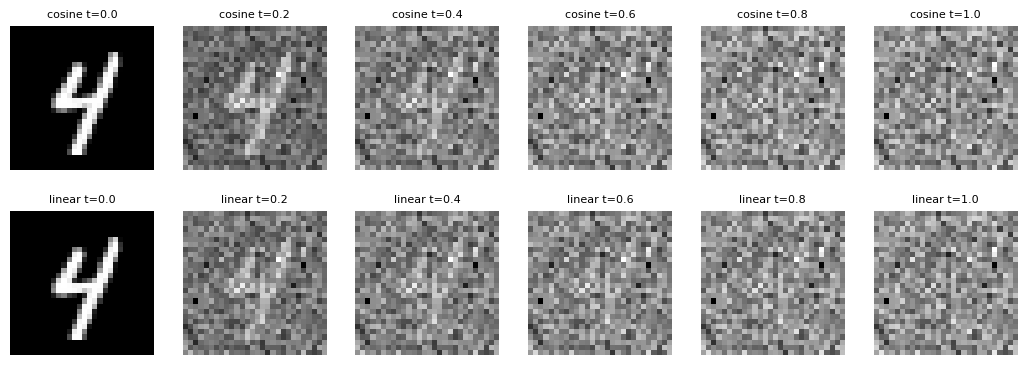

In [43]:
img9 = np.asarray(datasets.load_mnist(train=True, n=1, seed=5)[0][0]).squeeze()
rng9 = np.random.default_rng(0)
noise9 = rng9.standard_normal(img9.shape)
fig, axes = plt.subplots(2, 6, figsize=(13, 4.4))
for j, t in enumerate([0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    for row, (name, a) in enumerate([("cosine", np.cos(t * np.pi / 2) ** 2), ("linear", 1 - t)]):
        axes[row, j].imshow(np.sqrt(a) * img9 + np.sqrt(1 - a) * noise9, cmap="gray")
        axes[row, j].axis("off")
        axes[row, j].set_title(f"{name} t={t:.1f}", fontsize=8)
plt.show()

### 演習 4・5 — 逆過程ステップ数と三峰性分布

ステップが少なすぎると分布の形が崩れます。三峰でも(モードが対称なら)復元できます。

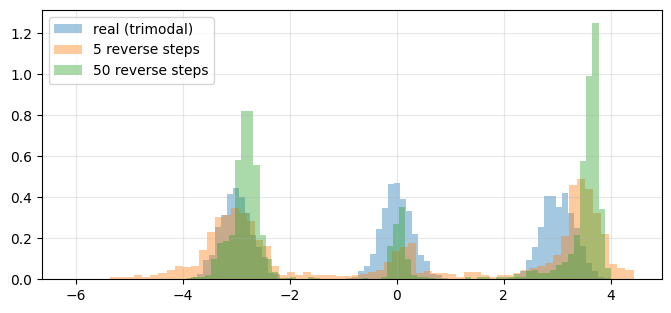

In [44]:
from nn_textbook.models import make_denoiser

def sample_trimodal(n, seed=0):
    r = np.random.default_rng(seed)
    comp = r.integers(0, 3, n)
    return (np.choose(comp, [-3.0, 0.0, 3.0]) + 0.3 * r.standard_normal(n)).astype(np.float32)

x0t = torch.tensor(sample_trimodal(4000))[:, None]
set_seed(0)
den = make_denoiser(input_dim=1, hidden=64)
opt = torch.optim.Adam(den.parameters(), 1e-3)
for _ in range(1500):
    idx = torch.randint(0, len(x0t), (256,))
    clean = x0t[idx]; tt = torch.rand(256, 1)
    a = torch.cos(tt * np.pi / 2) ** 2
    noisy = torch.sqrt(a) * clean + torch.sqrt(1 - a) * torch.randn_like(clean)
    loss = ((den(noisy, tt) - clean) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

@torch.no_grad()
def reverse(steps, n=2000):
    x = torch.randn(n, 1) * 2.5
    for s in reversed(range(1, steps + 1)):
        tcol = torch.full((n, 1), s / steps)
        x0p = den(x, tcol)
        a_now = float(np.cos(s / steps * np.pi / 2) ** 2)
        a_nxt = float(np.cos((s - 1) / steps * np.pi / 2) ** 2)
        eps = (x - np.sqrt(a_now) * x0p) / np.sqrt(1 - a_now + 1e-6)
        x = np.sqrt(a_nxt) * x0p + np.sqrt(1 - a_nxt) * eps
    return x.ravel().numpy()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(x0t.ravel().numpy(), bins=70, density=True, alpha=0.4, label="real (trimodal)")
for steps in [5, 50]:
    ax.hist(reverse(steps), bins=70, density=True, alpha=0.4, label=f"{steps} reverse steps")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 演習 6(発展)— 2 次元リングの拡散

同じ枠組みを 2 次元に上げるだけです(`input_dim=2`)。生成点がリングを再現します。

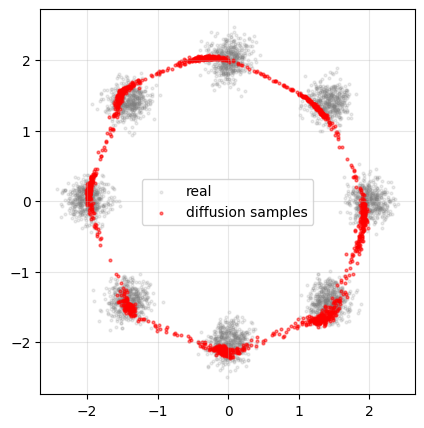

In [45]:
Xr, _ = datasets.make_gaussian_mixture_dataset(n=4000, n_components=8, radius=2.0, std=0.15, seed=0)
x0r = torch.tensor(Xr)
set_seed(0)
den2 = make_denoiser(input_dim=2, hidden=128)
opt = torch.optim.Adam(den2.parameters(), 1e-3)
for _ in range(2500):
    idx = torch.randint(0, len(x0r), (256,))
    clean = x0r[idx]; tt = torch.rand(256, 1)
    a = torch.cos(tt * np.pi / 2) ** 2
    noisy = torch.sqrt(a) * clean + torch.sqrt(1 - a) * torch.randn_like(clean)
    loss = ((den2(noisy, tt) - clean) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

@torch.no_grad()
def reverse2(steps=50, n=1500):
    x = torch.randn(n, 2) * 2.5
    for s in reversed(range(1, steps + 1)):
        tcol = torch.full((n, 1), s / steps)
        x0p = den2(x, tcol)
        a_now = float(np.cos(s / steps * np.pi / 2) ** 2)
        a_nxt = float(np.cos((s - 1) / steps * np.pi / 2) ** 2)
        eps = (x - np.sqrt(a_now) * x0p) / np.sqrt(1 - a_now + 1e-6)
        x = np.sqrt(a_nxt) * x0p + np.sqrt(1 - a_nxt) * eps
    return x.numpy()

gen2 = reverse2()
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Xr[:, 0], Xr[:, 1], s=4, alpha=0.15, color="gray", label="real")
ax.scatter(gen2[:, 0], gen2[:, 1], s=4, alpha=0.5, color="red", label="diffusion samples")
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 10 章の解答

### 演習 1 — 文字 vs 単語の系列長

同じ文でも文字レベルは数倍長くなります。BPE は「頻出パターンを 1 トークンにまとめる」ことで
両者の中間(短い系列 + 小さめ語彙)を実現します。

In [46]:
text10 = datasets.make_tiny_text_corpus()
sent = "neural networks learn representations from data."
print(f"chars : {len(sent)} tokens")
print(f"words : {len(sent.split())} tokens")
print(f"ratio : {len(sent) / len(sent.split()):.1f}x")

chars : 48 tokens
words : 6 tokens
ratio : 8.0x


### 演習 2 — SVD 埋め込みでの検索

bag-of-words は表記一致しか拾えませんが、共起 SVD 埋め込みは
「同じ文脈に出る語」を近づけるため、表記が違っても意味的に近い文書が上がります。

In [47]:
words10 = text10.replace(".", " .").split()
vocab10 = sorted(set(words10)); idx10 = {w: i for i, w in enumerate(vocab10)}
co = np.zeros((len(vocab10), len(vocab10)))
for i in range(len(words10) - 1):
    a, b = idx10[words10[i]], idx10[words10[i + 1]]
    co[a, b] += 1; co[b, a] += 1
U, s, _ = np.linalg.svd(np.log1p(co))
emb10 = U[:, :8] * s[:8]

def embed_sentence(sent):
    vs = [emb10[idx10[w]] for w in sent.lower().split() if w in idx10]
    return np.mean(vs, axis=0) if vs else np.zeros(8)

docs10 = ["neural networks learn representations from data",
          "attention lets tokens look at each other",
          "gradient descent minimizes the loss function",
          "the model predicts the next token"]
q = embed_sentence("how do neural language models learn")
scores = [float(q @ embed_sentence(d) / (np.linalg.norm(q) * np.linalg.norm(embed_sentence(d)) + 1e-9)) for d in docs10]
for i in np.argsort(scores)[::-1]:
    print(f"  {scores[i]:+.3f}  {docs10[i]!r}")

  +0.832  'neural networks learn representations from data'
  +0.127  'attention lets tokens look at each other'
  -0.021  'the model predicts the next token'
  -0.032  'gradient descent minimizes the loss function'


### 演習 3 — LoRA のランクと表現力

In [48]:
from nn_textbook.models import LoRALinear

rng10 = np.random.default_rng(0)
W0 = rng10.standard_normal((200, 200))
for r in [1, 4, 16]:
    lora = LoRALinear(W0, rank=r, alpha=2 * r)
    lora.A = rng10.standard_normal(lora.A.shape) * 0.1
    lora.B = rng10.standard_normal(lora.B.shape) * 0.1
    delta = lora.effective_weight() - W0
    print(f"rank={r:>2}: params={lora.n_lora_params():>6,}  matrix_rank(update)={np.linalg.matrix_rank(delta)}")

rank= 1: params=   400  matrix_rank(update)=1
rank= 4: params= 1,600  matrix_rank(update)=4
rank=16: params= 6,400  matrix_rank(update)=16


### 演習 4 — 好みの対象を変える

ペアの向きを変えるだけで、最適化は新しい「勝者」に確率を寄せます。
モデルは好みデータの写し鏡です。

In [49]:
torch.manual_seed(0)
logits10 = torch.zeros(3, requires_grad=True)
opt = torch.optim.SGD([logits10], lr=0.5)
pairs = [(2, 0), (2, 1), (2, 0)]          # now response 2 is preferred
for _ in range(60):
    opt.zero_grad()
    loss = -sum(F.logsigmoid(logits10[w] - logits10[loser]) for w, loser in pairs)
    loss.backward(); opt.step()
print("final P(response):", F.softmax(logits10.detach(), 0).numpy())

final P(response): [0.006 0.01  0.984]


### 演習 5 — 生成温度(07 章の解答 5 と同じ機構)

低温 → 高頻度パターンの反復、高温 → 崩れた綴り。バランス点を探すのが実務です
(07 章解答 5 のコードがそのまま使えます)。

### 演習 6(発展)— スケーリング則の指数

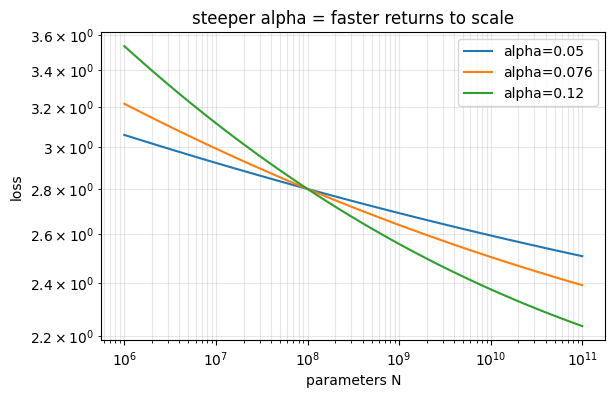

In [50]:
N = np.logspace(6, 11, 100)
plt.figure(figsize=(6.5, 4))
for alpha in [0.05, 0.076, 0.12]:
    plt.loglog(N, 1.8 + (1e8 / N) ** alpha, label=f"alpha={alpha}")
plt.xlabel("parameters N"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("steeper alpha = faster returns to scale")
plt.show()

## 11 章(付録)の解答

### 演習 1 — メモリ限界の探り方

`torch.cuda.OutOfMemoryError` を捕まえて段階的に下げるのが定石です(実行は環境依存のため省略)。

```python
for n in [8192, 16384, 32768]:
    try:
        a = torch.randn(n, n, device="cuda")
        b = torch.randn(n, n, device="cuda")
        (a @ b).sum().item()
        print(n, "ok")
    except torch.cuda.OutOfMemoryError:
        print(n, "OOM"); break
    finally:
        del a, b; torch.cuda.empty_cache()
```

### 演習 2・4・5 — チャネル増・bfloat16・系列長

方向性: チャネル 4 倍で計算量はほぼ 16 倍になり GPU 優位が拡大。
bfloat16 は fp16 と同等速度で、指数部が広くオーバーフローに強い(学習で好まれる)。
系列長 2 倍で注意の計算は約 4 倍($O(T^2)$)。
小さなスケールで bf16 と系列長だけ確認します。

In [51]:
from nn_textbook import benchmark

devices11 = benchmark.available_devices()
if "cuda" in devices11:
    for dt in [torch.float16, torch.bfloat16]:
        recs = benchmark.benchmark_matmul([2048], devices=["cuda"], dtype=dt, n_iters=20)
        print(f"{str(dt):16s}: n=2048 -> {recs[0]['ms']:.3f} ms")
else:
    print("no GPU: skipping bf16 comparison")

torch.float16   : n=2048 -> 0.160 ms
torch.bfloat16  : n=2048 -> 0.194 ms


In [52]:
# Sequence length scaling of one attention block (CPU, tiny, qualitative).
from nn_textbook.models import make_transformer_block

blk = make_transformer_block(d_model=64, n_heads=4)
for T in [64, 256]:
    x = torch.randn(8, T, 64)
    ms = 1000 * benchmark.time_callable(lambda: blk(x), device="cpu", n_warmup=2, n_iters=5)
    print(f"T={T:>3}: forward {ms:7.2f} ms")
print("ratio should approach ~4x as attention dominates (O(T^2))")

T= 64: forward    0.34 ms
T=256: forward    1.00 ms
ratio should approach ~4x as attention dominates (O(T^2))


### 演習 3 — CPU スレッド数

小さな行列ではスレッドが多いほど **遅くなる** ことがあります(ディスパッチ・同期の固定費)。
大きな行列では多いほど速い。NB11 が `CPU_THREADS = 8` に絞っているのはこのためです。

### 演習 6 — GPU で 05 章を実行

```bash
NN_TEXTBOOK_GPU=1 uv run jupyter nbconvert --to notebook --execute \
  analytics/neural_net/notebooks/05_convolutional_neural_networks.ipynb --stdout > /dev/null
```

このマシン(RTX 5080)では CPU 実行の数分の一で完走します(11 章 §4 の speedup と整合)。